# Data Evaluation: Solvability (User Study Task 1)

## 0. Setup

In [1]:
import pandas as pd
import matplotlib as mpl
%matplotlib inline

data_df = pd.read_csv('../ma-eval/combined-data.csv')
data_df

,participant,p_id,date,group,s_iss_miro,s_tp_miro,s_fp_miro,s_iss_pixie,s_tp_pixie,s_fp_pixie,...,UEQS-4,UEQS-5,UEQS-6,UEQS-7,UEQS-8,C-Q1,C-Q2,C-Q3,C-Q4,Anything else you want to tell us?
0,1,MA12534,2026-06-29,AM,3,2,1,0,0,0,...,3,6,7,7,7,3,1,2,4,NaN
1,21,MA26593,2026-07-07,AM,1,1,0,0,0,0,...,3,5,6,7,6,3,4,4,4,NaN
2,13,MA34230,2026-07-01,AM,3,3,0,1,1,0,...,6,6,6,7,7,2,4,4,5,The locks need to be differentiable by look
3,5,MA7125,2026-06-30,AM,4,1,3,2,2,0,...,6,5,7,5,5,5,4,5,5,NaN
4,17,MA95137,2026-07-02,AM,2,2,0,0,0,0,...,2,7,7,6,5,5,4,4,5,It's nice to use but it takes some time to get...
5,9,MA95935,2026-06-30,AM,2,1,1,0,0,0,...,7,7,7,4,4,5,5,5,5,"Would have liked to have a ""total time needed ..."
6,15,MB10509,2026-07-02,BM,2,2,0,1,1,1,...,7,7,7,5,5,3,5,5,4,Tool did not make it clear which locks had whi...
7,7,MB24145,2026-06-30,BM,3,3,0,2,1,1,...,3,6,6,4,5,4,4,4,4,Please for gods sake put more contrast between...
8,23,MB41880,2026-07-07,BM,1,1,0,0,0,0,...,4,3,5,2,2,2,1,4,3,I feel like so much potential is wasted not in...
9,11,MB50964,2026-07-01,BM,2,2,0,4,2,2,...,5,7,7,6,6,4,4,4,5,i wasn't really sure what happened in the path...


## 1. Counts of Identified Issues

In [2]:
total_counts_solvability = [
    's_iss_miro',
    's_iss_pixie',
]

#### Distribution of Total Number of Identified Issues Across Participants By Tool

includes incorrect answers

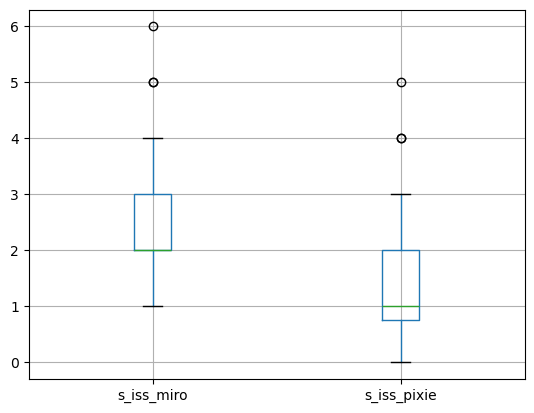

In [3]:
total_solvability_boxplot = data_df.boxplot(column=total_counts_solvability)

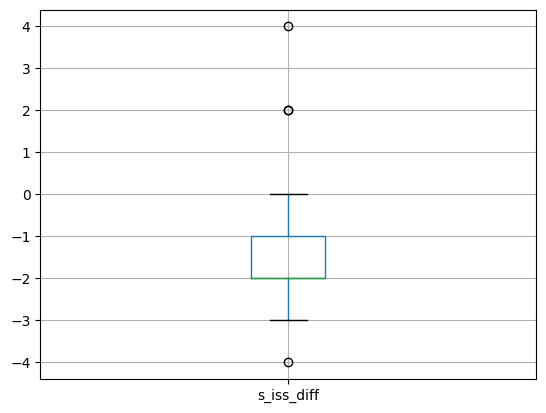

In [4]:
data_df['s_iss_diff'] = data_df['s_iss_pixie'] - data_df['s_iss_miro']
solvability_diff = data_df.boxplot(column=['s_iss_diff'])

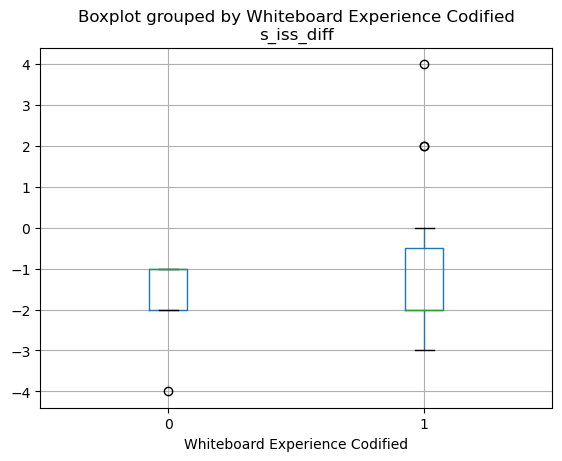

In [18]:
solvability_diff_by_wb_exp = data_df.boxplot(column=['s_iss_diff'], by="Whiteboard Experience Codified")

#### Distribution of Total Number of Identified Issues Across Participants By Tool And Group

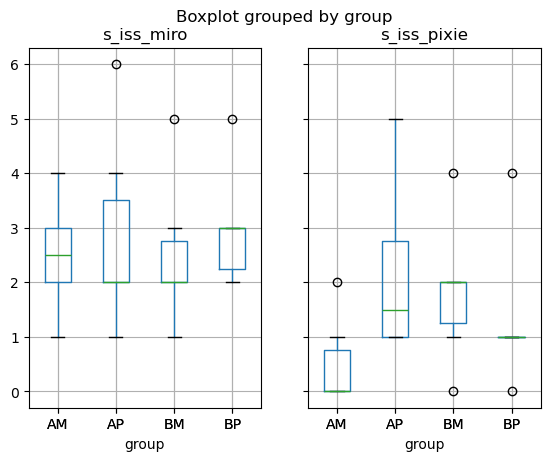

In [5]:
total_solvability_by_group_boxplot = data_df.boxplot(column=total_counts_solvability, by='group')

#### Distribution of Totl Number of Idfentified Issues Across Participants By Tool and Whiteboard Experience

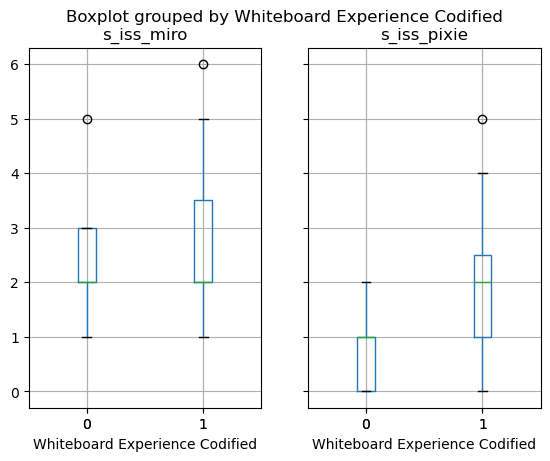

In [17]:
total_solvability_by_group_boxplot = data_df.boxplot(column=total_counts_solvability, by='Whiteboard Experience Codified')

### Precision

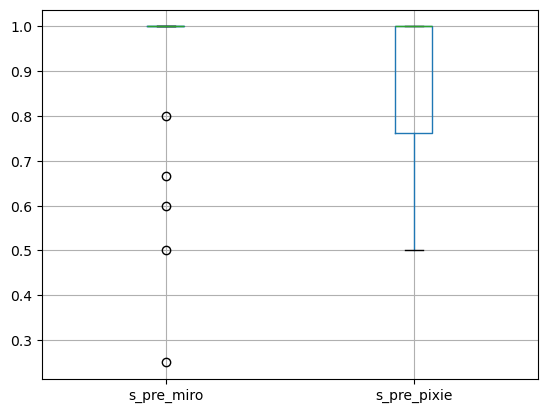

In [6]:
TOTAL_ISSUES = 6

data_df['s_pre_miro'] = data_df['s_tp_miro'] / data_df['s_iss_miro']
data_df['s_pre_pixie'] = data_df['s_tp_pixie'] / data_df['s_iss_pixie']

solvability_precision_boxplot = data_df.boxplot(column=['s_pre_miro', 's_pre_pixie'])

In [7]:
# NOTE: missing values for precision when 0 issues identified
data_df[['s_pre_miro', 's_pre_pixie']].describe()

,s_pre_miro,s_pre_pixie
count,24.000000,18.000000
mean,0.909028,0.873148
std,0.200541,0.199111
min,0.250000,0.500000
25%,1.000000,0.762500
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


### Recall

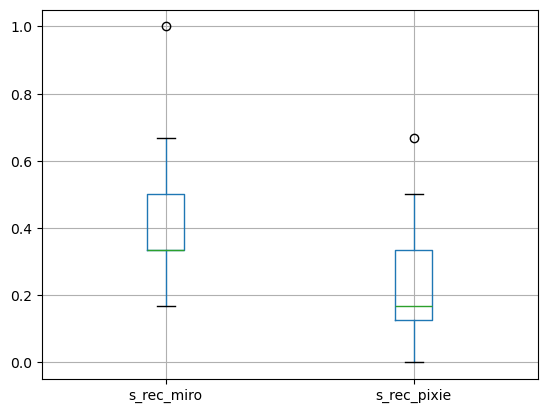

In [8]:
data_df['s_rec_miro'] = data_df['s_tp_miro'] / TOTAL_ISSUES
data_df['s_rec_pixie'] = data_df['s_tp_pixie'] / TOTAL_ISSUES

solvability_recall_boxplot = data_df.boxplot(column=['s_rec_miro', 's_rec_pixie'])

In [48]:
data_df[['s_rec_miro', 's_rec_pixie']].describe()

,s_rec_miro,s_rec_pixie
count,24.000000,24.000000
mean,0.395833,0.194444
std,0.195434,0.167870
min,0.166667,0.000000
25%,0.333333,0.125000
50%,0.333333,0.166667
75%,0.500000,0.333333
max,1.000000,0.666667


### F1

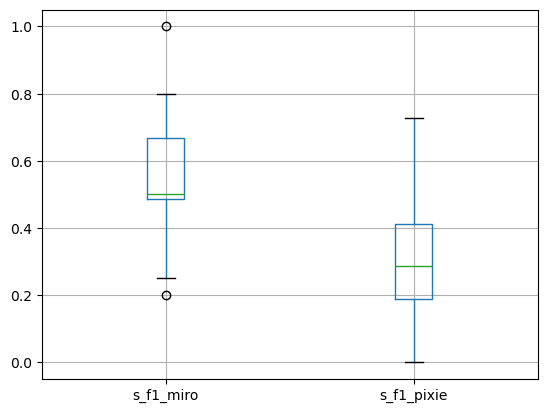

In [9]:
data_df['s_f1_miro'] = 2 * data_df['s_tp_miro'] / (2 * data_df['s_tp_miro'] + data_df['s_fp_miro'] + (TOTAL_ISSUES - data_df['s_tp_miro']))
data_df['s_f1_pixie'] = 2 * data_df['s_tp_pixie'] / (2 * data_df['s_tp_pixie'] + data_df['s_fp_pixie'] + (TOTAL_ISSUES - data_df['s_tp_pixie']))
solvability_f1_boxplot = data_df.boxplot(column=['s_f1_miro', 's_f1_pixie'])

In [10]:
data_df[['s_f1_miro', 's_f1_pixie']].describe()

# TODO: investigate missing value

,s_f1_miro,s_f1_pixie
count,24.000000,24.000000
mean,0.525508,0.277161
std,0.187462,0.202259
min,0.200000,0.000000
25%,0.486111,0.187500
50%,0.500000,0.285714
75%,0.666667,0.411111
max,1.000000,0.727273


#### F1 Difference Per Participant

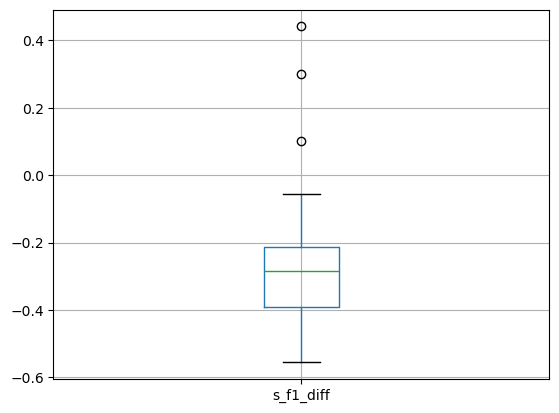

In [11]:
data_df['s_f1_diff'] = data_df['s_f1_pixie'] - data_df['s_f1_miro']
solvability_f1_diff = data_df.boxplot(column=['s_f1_diff'])

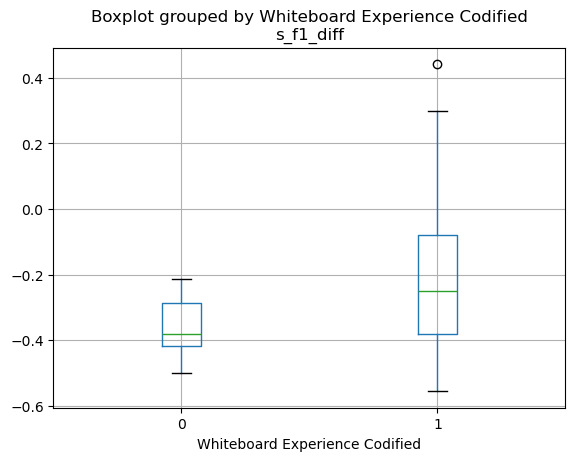

In [16]:
solvability_f1_diff_by_wb_exp = data_df.boxplot(column=['s_f1_diff'], by='Whiteboard Experience Codified')

In [12]:
data_df['s_f1_diff'].describe()

count    24.000000
mean     -0.248347
std       0.243312
min      -0.555556
25%      -0.389881
50%      -0.285714
75%      -0.214286
max       0.441558
Name: s_f1_diff, dtype: float64

#### F1 Stratified By Group

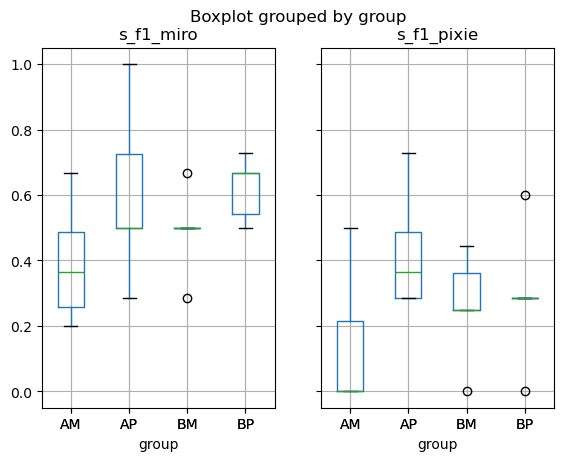

In [13]:
solvability_f1_by_group_boxplot = data_df.boxplot(column=['s_f1_miro', 's_f1_pixie'], by='group')

#### F1 Stratified By Whiteboard Experience

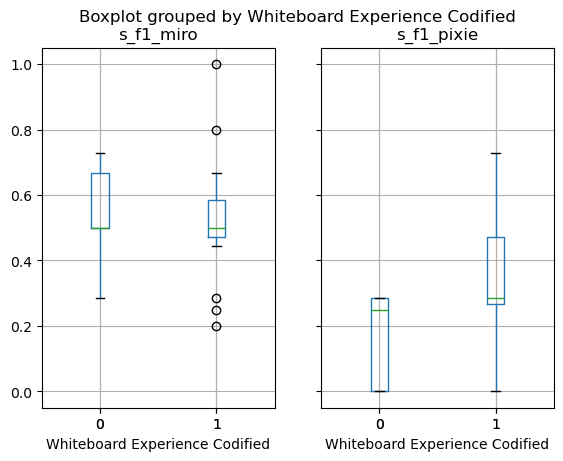

In [15]:
solvability_f1_by_whiteboard_exp_boxplot = data_df.boxplot(column=['s_f1_miro', 's_f1_pixie'], by='Whiteboard Experience Codified')

## 2. Issues In Time

In [52]:
timeseries_data_df = pd.read_csv('../eval-toolchain/time_series/all.csv')
timeseries_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
0,PA40344,AP,solvability_pixie,LA_3,01:27:30,STA,NaN,0
1,PA40344,AP,solvability_pixie,LA_3,01:27:44,OBS,pathfinding start-room after boss,14
2,PA40344,AP,solvability_pixie,LA_3,01:28:08,vb,ath blocked to boss,38
3,PA40344,AP,solvability_pixie,LA_3,01:28:45,OBS,successive pathfinding,75
4,PA40344,AP,solvability_pixie,LA_3,01:28:56,vb,oftlock 14,86
...,...,...,...,...,...,...,...,...
819,PA38184,AP,pacing_miro,LA_2,14:43:59,Q2A,A takes longer than B,162
820,PA38184,AP,pacing_miro,LA_2,14:44:08,Q4A,room 15,171
821,PA38184,AP,pacing_miro,LA_2,14:45:09,Q3A,"no, B has more enemies than C",232
822,PA38184,AP,pacing_miro,LA_2,14:46:07,Q5A,21-2 to 21-3,290


In [53]:
issues_data_df = timeseries_data_df[timeseries_data_df['tag'] == 'ISS']
issues_data_df

,p_id,group,task,map,timestamp,tag,note,timedelta
31,MA7125,AM,solvability_pixie,LA_4,11:32:16,ISS,? missing key between 31 and Boss,78
32,MA7125,AM,solvability_pixie,LA_4,11:33:16,ISS,TP 12 not reachable,138
35,MA7125,AM,solvability_pixie,LA_4,11:36:42,ISS,TP one-directional path 12-11,344
39,MA7125,AM,solvability_miro,LA_3,11:27:20,ISS,cannot got further than marked path (evl: incl...,231
40,MA7125,AM,solvability_miro,LA_3,11:27:49,ISS,TP one-directional path 12-15,260
...,...,...,...,...,...,...,...,...
772,MB67500,BM,solvability_miro,LA_4,15:25:46,ISS,TP can't get to area 28 bc one-directional edge,205
797,PA38184,AP,solvability_pixie,LA_3,14:26:16,ISS,TP need 6 bombs for 22-23 but only get one on ...,270
802,PA38184,AP,solvability_miro,LA_4,14:29:18,ISS,TP can't unlock edge 6 - 12,92
804,PA38184,AP,solvability_miro,LA_4,14:30:18,ISS,? can't unlock 12-11 (ability unreachable),152


In [54]:
first_issues_df = issues_data_df.loc[issues_data_df.groupby(['p_id', 'task']).timedelta.idxmin()]
first_issues_df

,p_id,group,task,map,timestamp,tag,note,timedelta
629,MA12534,AM,solvability_miro,LA_3,11:21:21,ISS,"TP hard lock 6, pretty confident",159
69,MA26593,AM,solvability_miro,LA_3,11:23:57,ISS,TP softlock in 4 if ability check not passed,99
452,MA34230,AM,solvability_miro,LA_3,17:26:49,ISS,TP if bomb used on 13 - 14: softlock in 14,130
446,MA34230,AM,solvability_pixie,LA_4,17:36:46,ISS,TP 6-12 not unlockable,270
39,MA7125,AM,solvability_miro,LA_3,11:27:20,ISS,cannot got further than marked path (evl: incl...,231
31,MA7125,AM,solvability_pixie,LA_4,11:32:16,ISS,? missing key between 31 and Boss,78
373,MA95137,AM,solvability_miro,LA_3,15:26:14,ISS,TP hardlocked in 6,39
694,MA95935,AM,solvability_miro,LA_3,16:26:50,ISS,TP not enough bombs 22-23,156
313,MB10509,BM,solvability_miro,LA_4,13:27:50,ISS,"? can get to 31, but no further",127
304,MB10509,BM,solvability_pixie,LA_3,13:34:03,ISS,TP hardlock in 6,40


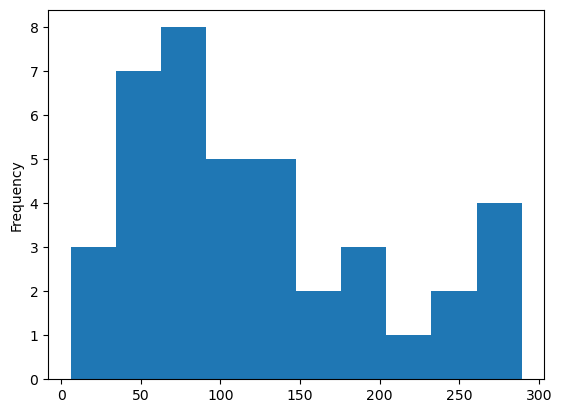

In [55]:

time_to_first_issue_hist = first_issues_df['timedelta'].plot.hist()
# time_to_first_issue_hist = first_issues_df.timedelta.plot.hist(groupby='task')
# time_to_first_issue_hist = first_issues_df.plot.hist('timadelta', by='task')

##### Distribution of First Issue Found Events Across Participants By Task

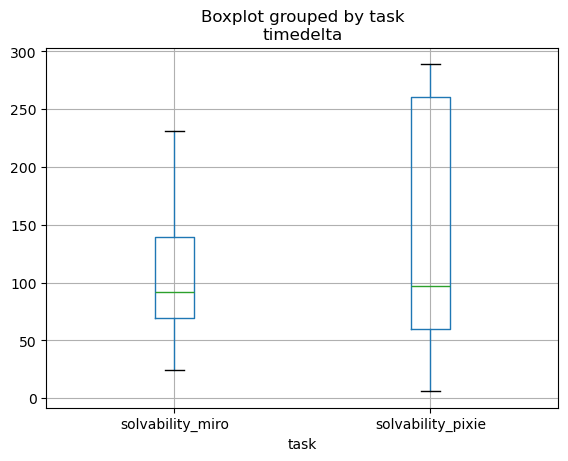

In [56]:
time_to_first_issue_box = first_issues_df.boxplot(by='task', column='timedelta')

##### Time To First Issue By Tool And Map

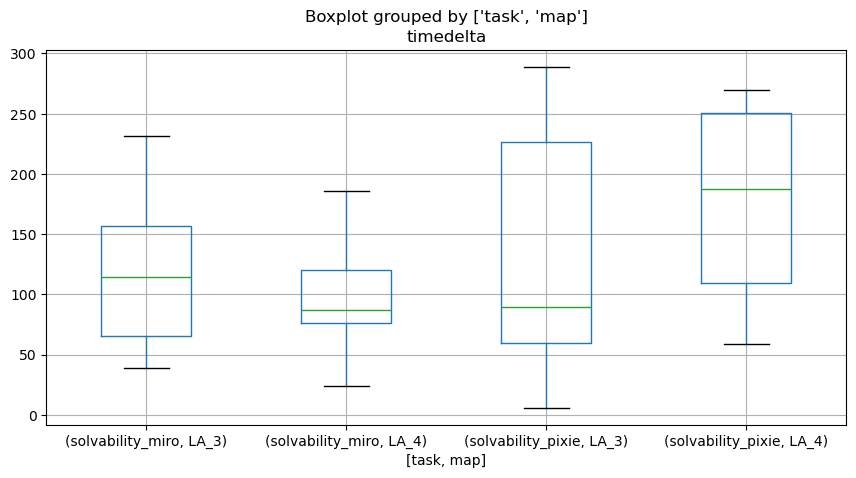

In [57]:
time_to_first_issue_box_task = first_issues_df.boxplot(by=['task', 'map'], column='timedelta', figsize=(10, 5))

##### Distribution of Issue Found Events Across Time

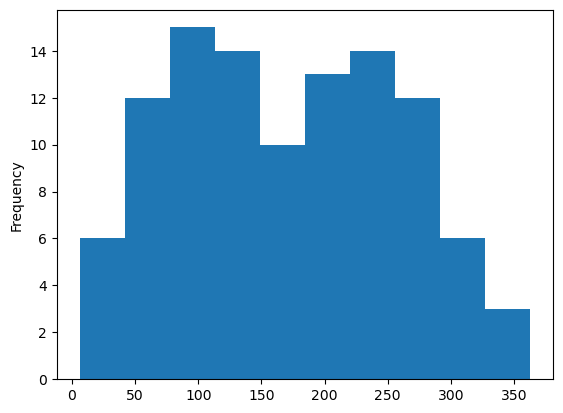

In [58]:
ax2 = issues_data_df['timedelta'].plot.hist()